<a href="https://colab.research.google.com/github/FarsusDasdana/multitarget_modeling_dl/blob/main/multitarget_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Libs.

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

## Data Prep

In [ ]:
data = pd.read_parquet("/content/tat_prep.parquet")
data = data.rename(columns={"CustomerCode":"customer", "productCode":"product","OrderQuantity_cnl":"quantity"})
data.head(2)

,customer,product,date,quantity,t,e
0,0011000001,30000291,2021-09-30,12.0,NaN,1
1,0011000001,30000291,2021-10-31,0.0,1.0,0


In [ ]:
values_cols = ["e","quantity"]
grp = ["customer","product"]
shifts = range(-2,7)


for values_col in values_cols:
  for shift in shifts:
    if(values_col == "e") & (shift >=0):
      continue

    if shift > 0:
      data[f'{values_col}_shifted_{shift}'] = data.groupby(grp)[values_col].shift(shift).diff()
    elif shift == 0:
      continue
    else:
      data[f'{values_col}_in_{-shift}_periods'] = data.groupby(grp)[values_col].shift(shift)

data.head()

,customer,product,date,quantity,t,e,e_in_2_periods,e_in_1_periods,quantity_in_2_periods,quantity_in_1_periods,quantity_shifted_1,quantity_shifted_2,quantity_shifted_3,quantity_shifted_4,quantity_shifted_5,quantity_shifted_6
0,0011000001,30000291,2021-09-30,12.0,NaN,1,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,0011000001,30000291,2021-10-31,0.0,1.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,0011000001,30000291,2021-11-30,0.0,2.0,0,0.0,0.0,0.0,0.0,-12.0,NaN,NaN,NaN,NaN,NaN
3,0011000001,30000291,2021-12-31,0.0,3.0,0,0.0,0.0,0.0,0.0,0.0,-12.0,NaN,NaN,NaN,NaN
4,0011000001,30000291,2022-01-31,0.0,4.0,0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,NaN,NaN,NaN


In [ ]:
from sklearn.utils import resample

def downsample(data):
  data_0 = data[data['e'] == 0]
  data_1 = data[data['e'] == 1]

  size_0 = len(data_0)
  size_1 = len(data_1)

  if size_0 >= size_1:
    downsampled = resample(data_0,
                           replace=True,
                           n_samples=size_1,
                           random_state=52)
    data = pd.concat([downsampled, data_1])
  elif size_1 >= size_0:
    downsampled = resample(data_1,
                           replace=True,
                           n_samples=size_0,
                           random_state=52)
    data = pd.concat([downsampled, data_0])
  else:
    print("something went wrong about shape of classes: ", size_0, size_1)

  return data.reset_index(drop=True)

In [ ]:
print(data.e.value_counts(),"\n")
data = downsample(data)
print(data.e.value_counts())

0    402331
1    179472
Name: e, dtype: int64 

0    179472
1    179472
Name: e, dtype: int64


In [ ]:
threshold = "2022-05-31"



le_prod = LabelEncoder().fit(data["product"])
le_cus = LabelEncoder().fit(data["customer"])

data["product"] = le_prod.transform(data["product"])
data["customer"] = le_cus.transform(data["customer"])

train = data[data.date < threshold].drop(columns=["date"]).dropna()
test = data[data.date >= threshold].drop(columns=["date"]).dropna()

"""le_prod = LabelEncoder().fit(train["product"])
le_cus = LabelEncoder().fit(train["customer"])

train["product"] = le_prod.transform(train["product"])
test["product"] = le_prod.transform(test["product"])
train["customer"] = le_cus.transform(train["customer"])
test["customer"] = le_cus.transform(test["customer"])"""

print("train: ", train.shape)
print("test: ", test.shape)

train:  (195727, 15)
test:  (12229, 15)


In [ ]:
y_targets = [n for n in data.columns if "quantity_in_" in n]
e_targets = [n for n in data.columns if "e_in_" in n]


xtr = train.drop(columns=["quantity","e"]).values
ytr = train[y_targets + e_targets].values
xtst = test.drop(columns=["quantity","e"]).values
ytst = test[y_targets + e_targets].values

print("xtr: ", xtr.shape)
print("ytr: ", ytr.shape)
print("xtst: ", xtst.shape)
print("ytst: ", ytst.shape)

xtr:  (195727, 13)
ytr:  (195727, 4)
xtst:  (12229, 13)
ytst:  (12229, 4)


In [ ]:
def multi_target_output(data):
  y1,y2,y3,y4 = [],[],[],[]
  for y in data:
    y1.append(y[0])
    y2.append(y[1])
    y3.append(y[2])
    y4.append(y[3])
  return (np.array(y1),np.array(y2),np.array(y3),np.array(y4))


y_tr = multi_target_output(ytr)
y_tst = multi_target_output(ytst)

print("y_tr: ",np.shape(y_tr))
print("y_tst: ",np.shape(y_tst))

y_tr:  (4, 195727)
y_tst:  (4, 12229)


## Modeling

In [ ]:
def build_model_with_functional(input_shape, output_shape, show=False):

    # set random state
    tf.random.set_seed(5252)

    # Input layers
    input_layer = tf.keras.Input(shape=(input_shape,))
    first_dense = tf.keras.layers.Dense(64, activation=tf.nn.relu)(input_layer)
    second_dense = tf.keras.layers.Dense(64, activation=tf.nn.relu)(first_dense)
    third_dense = tf.keras.layers.Dense(32, activation=tf.nn.relu)(second_dense)

    # y1 forecast
    y1_output = tf.keras.layers.Dense(units=1, name='y1_output')(first_dense)
    # y2 forecast
    y2_output = tf.keras.layers.Dense(units=1, name='y2_output')(first_dense)
    # y3 forecast
    y3_output = tf.keras.layers.Dense(units=1, name='y3_output')(first_dense)
    # y4 forecast
    y4_output = tf.keras.layers.Dense(units=1, name='y4_output')(first_dense)

    # define model
    func_model = tf.keras.models.Model(inputs=input_layer, outputs=[y1_output,
                                                                    y2_output,
                                                                    y3_output,
                                                                    y4_output])

    if show:
      print(func_model.summary())


    return func_model

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.utils import plot_model

# inherit from the Model base class
class ModelV1(Model):
    def __init__(self, units=12, filters=64, kernel_size=12, activation='relu', **kwargs):
        '''initializes the instance attributes'''
        super().__init__(**kwargs)
        self.exp_dim = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))
        self.conv_1d = tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, activation=activation)
        self.batch_norm = tf.keras.layers.BatchNormalization()
        self.bi_lstm = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units, return_sequences=False))
        self.dense1 = tf.keras.layers.Dense(units, activation=activation)
        self.dense2 = tf.keras.layers.Dense(units, activation=activation)
        self.dense_cls1 = tf.keras.layers.Dense(units, activation=activation)

        self.output_y1 = tf.keras.layers.Dense(1)
        self.output_y2 = tf.keras.layers.Dense(1)
        self.output_e1 = tf.keras.layers.Dense(1, 'sigmoid')
        self.output_e2 = tf.keras.layers.Dense(1, 'sigmoid')

    def call(self, inputs):
        '''defines the network architecture'''

        exp_dim = self.exp_dim(inputs)
        conv_1d = self.conv_1d(exp_dim)
        batch_norm = self.batch_norm(conv_1d)

        bi_lstm = self.bi_lstm(batch_norm)

        concat = tf.keras.layers.concatenate([inputs, bi_lstm])

        dense_1 = self.dense1(concat)
        dense_2 = self.dense2(dense_1)
        dense_cls1 = self.dense_cls1(dense_1)

        output_1 = self.output_y1(dense_2)
        output_2 = self.output_y2(dense_2)

        output_3 = self.output_e1(dense_cls1)
        output_4 = self.output_e2(dense_cls1)

        return output_1, output_2, output_3, output_3

In [ ]:
# define model
model = ModelV1()


# train & predict
huber_threshold = 0.1
model.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-5),
              loss={'output_1': tf.keras.losses.MeanAbsoluteError(),
                    'output_2': tf.keras.losses.MeanAbsoluteError(),
                    'output_3': tf.keras.losses.BinaryCrossentropy(),
                    'output_4': tf.keras.losses.BinaryCrossentropy()})

history = model.fit(xtr, y_tr,
                    epochs=500,
                    callbacks=tf.keras.callbacks.EarlyStopping(monitor='loss',
                                                               min_delta=1e-5,
                                                               patience=10),
                    verbose=0)

y_preds = model.predict(xtst)
predictions = np.column_stack((y_preds[0],
                               y_preds[1],
                               y_preds[2],
                               y_preds[3]))
predictions = predictions.round(2)


# model evaluate
error = ytst - predictions
bayes_error = ytst-ytr.mean(axis=0)

print('** MSE **')
print("bayes mse: ",(bayes_error**2).mean(axis=0).round(4))
print('mse:       ', np.mean(error**2,axis=0).round(4),'\n')

print('** MAE **')
print("bayes mae: ",abs(bayes_error).mean(axis=0).round(4))
print('mae:       ', np.mean(abs(error),axis=0).round(4))

plt.plot(history.history["loss"])
plt.title('Learning Curve');

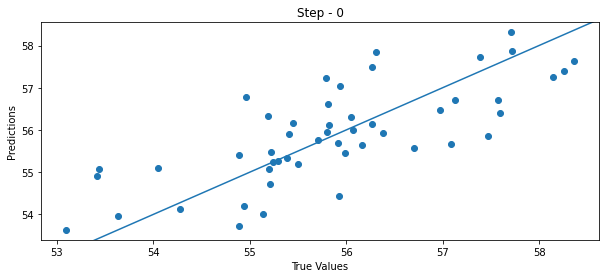

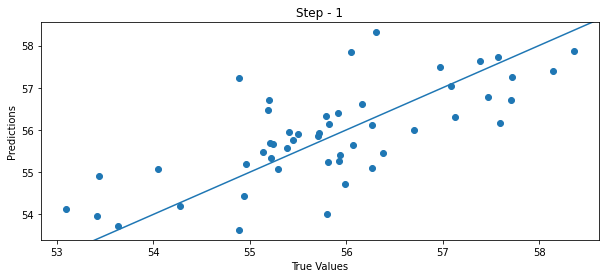

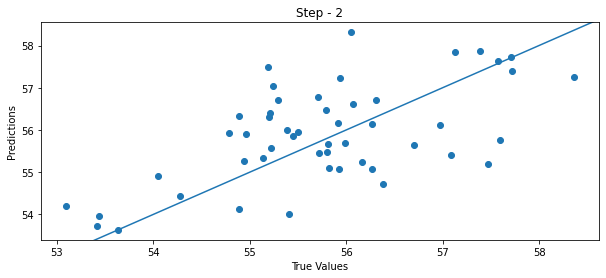

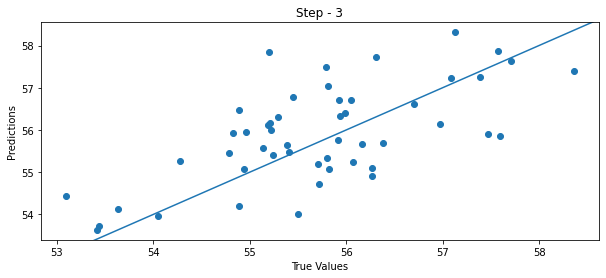

In [ ]:
# results
for i in range(4):
  t = 'Step - ' + str(i)

  plt.figure(figsize=(10,4))
  plt.scatter(y_tst[i], y_preds[i])
  plt.title(t)
  plt.xlabel('True Values')
  plt.ylabel('Predictions')
  plt.xlim(plt.xlim())
  plt.ylim(plt.ylim())
  plt.plot([-100, 500], [-100, 500])
  plt.show()